[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sibbirhossain/finguard-xai/blob/main/notebooks/04_unseen_fraud_generalization.ipynb)

# 04 · Catching Fraud the Model Has Never Seen

**Question:** *what happens when criminals use a tactic that was never in the training data?*

This is the central weakness of supervised fraud models. They learn yesterday's fraud.

**Experiment.** Account-takeover (ATO) fraud is removed completely from the training and validation data. It appears only in the future test period, as a genuinely new attack pattern. The experiment is repeated over 5 seeds.

**Finding that led to the design.** The first version fused the GNN and the anomaly detector with a learned stacker. Because validation data contains no novel fraud, the stacker learned to *ignore* the anomaly signal, and unseen ATO recall collapsed.

**Solution: dual-channel alerting.** A second, independent *novelty channel* alerts whenever a transaction's anomaly score exceeds the 99.5th percentile of legitimate validation traffic. That is a fixed, auditable false-positive budget reserved for the unknown.

In [1]:
# --- Setup: works in Google Colab and inside a local clone ---
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")
if os.path.exists("../src/models"):
    os.chdir("..")
elif not os.path.exists("src/models"):
    if not os.path.exists("finguard-xai"):
        subprocess.run(["git", "clone", "-q", "https://github.com/sibbirhossain/finguard-xai.git"], check=True)
    os.chdir("finguard-xai")
try:
    import torch_geometric  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"], check=True)
sys.path.insert(0, os.getcwd())
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("ready:", os.getcwd())

ready: /home/claude/finguard-xai


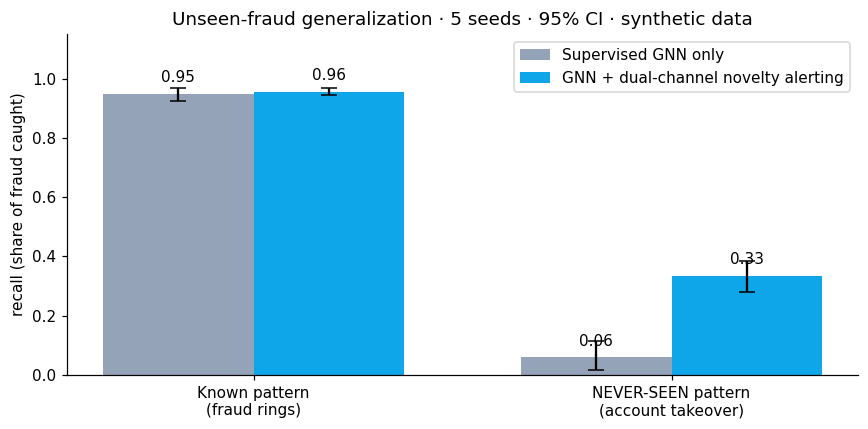

In [2]:
exp = json.loads(open("reports/EXPERIMENTS.json").read())
u = exp["unseen_ato"]
g, h = u["gnn_recall_by_scenario"], u["hybrid_recall_by_scenario"]
labels = ["Known pattern\n(fraud rings)", "NEVER-SEEN pattern\n(account takeover)"]
gnn = [g["ring"][0], g["ato"][0]]; hyb = [h["ring"][0], h["ato"][0]]
err = lambda d: [[d[k][0] - d[k][2] for k in ("ring", "ato")], [d[k][3] - d[k][0] for k in ("ring", "ato")]]
x = np.arange(2); w = .36
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, gnn, w, yerr=err(g), capsize=5, label="Supervised GNN only", color="#94a3b8")
ax.bar(x + w/2, hyb, w, yerr=err(h), capsize=5, label="GNN + dual-channel novelty alerting", color="#0ea5e9")
for i in range(2):
    ax.text(i - w/2, gnn[i] + .04, f"{gnn[i]:.2f}", ha="center"); ax.text(i + w/2, hyb[i] + .04, f"{hyb[i]:.2f}", ha="center")
ax.set_xticks(x, labels); ax.set_ylim(0, 1.15); ax.set_ylabel("recall (share of fraud caught)"); ax.legend()
ax.set_title("Unseen-fraud generalization · 5 seeds · 95% CI · synthetic data"); plt.tight_layout(); plt.show()

In [3]:
import pandas as pd
rows = {m: {"PR-AUC": u[m]["pr_auc"][0], "recall": u[m]["recall"][0], "precision": u[m]["precision"][0], "false-positive rate": u[m]["fpr"][0]}
        for m in ("gnn_only", "hybrid_gnn_plus_anomaly")}
pd.DataFrame(rows).T.round(4)

,PR-AUC,recall,precision,false-positive rate
gnn_only,0.7569,0.5853,0.9127,0.0019
hybrid_gnn_plus_anomaly,0.7331,0.7045,0.7237,0.0091


### Interpretation (including the cost)
- The novelty channel recovers part of the never-seen fraud that the supervised model misses entirely.
- The price is a higher false-positive rate. The budget is set by one parameter (`novelty_fpr`, default 0.5% of legitimate traffic), so an institution can tune it to its review capacity.
- This is a **measured trade-off on synthetic data**, not a guarantee. Testing the same protocol on public data (notebook 07) is the next step.